# GuidaPlate — LSTM v3 (Clinical Labels + Masking + Scaling)
## Notebook 05c — Improved temporal classifier

**Does not modify** notebooks 05/05b or `models/lstm_v2_final.keras`.

Combines B2 occasion features with controlled preprocessing (train-only scaler,
explicit padded-slot zero-out, truncated augmentation) and v3 clinical-score labels.


In [1]:
import os
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, roc_curve, auc,
)
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')
%matplotlib inline

RANDOM_STATE = 42
TEST_SIZE = 0.2
RISK_CLASSES = ['LOW', 'MODERATE', 'HIGH']
RISK_ENCODE = {c: i for i, c in enumerate(RISK_CLASSES)}
NUTRIENT_NAMES = ['potassium', 'phosphorus', 'protein', 'sodium']

def project_root() -> Path:
    p = Path.cwd().resolve()
    if p.name == 'notebooks':
        return p.parent
    if (p / 'data' / 'processed' / 'ckd_cohort_final.csv').exists():
        return p
    if (p.parent / 'data' / 'processed' / 'ckd_cohort_final.csv').exists():
        return p.parent
    return p

ROOT = project_root()
FIG_DIR = ROOT / 'outputs' / 'figures'
STATS_DIR = ROOT / 'outputs' / 'stats'
MODEL_DIR = ROOT / 'models'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(STATS_DIR, exist_ok=True)
print(f'Project root: {ROOT}')
print(f'TensorFlow {tf.__version__} | GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')


Project root: /Users/jade/GUIDAPLATE
TensorFlow 2.16.2 | GPU: False


## Section 1 — Setup & Data Loading


In [2]:
cache = np.load(MODEL_DIR / 'lstm_sequences_cache_v2.npz', allow_pickle=True)
X_seq = cache['sequences']
y_seq_orig = cache['labels']
patient_ids = cache['patient_ids']

labels_v3 = pd.read_csv(STATS_DIR / '05_risk_labels_v3.csv')
label_map = labels_v3.set_index('SEQN')['risk_label'].to_dict()
orig_map = labels_v3.set_index('SEQN')['risk_label_original'].to_dict()

y_seq_v3 = np.array([label_map.get(seqn, y_seq_orig[i]) for i, seqn in enumerate(patient_ids)])
y_seq_orig_from_csv = np.array([orig_map.get(seqn, y_seq_orig[i]) for i, seqn in enumerate(patient_ids)])

print(f'Sequences: {X_seq.shape}  (1830 × 6 × 5)')
print(f'Patients: {len(patient_ids)}')
print('\nOriginal label distribution (LSTM cohort):')
print(pd.Series(y_seq_orig_from_csv).value_counts().reindex(RISK_CLASSES))
print('\nv3 label distribution (LSTM cohort):')
print(pd.Series(y_seq_v3).value_counts().reindex(RISK_CLASSES))
changed = (y_seq_orig_from_csv != y_seq_v3).sum()
print(f'\nLabels changed original→v3: {changed} ({100*changed/len(y_seq_v3):.1f}%)')


Sequences: (1830, 6, 5)  (1830 × 6 × 5)
Patients: 1830

Original label distribution (LSTM cohort):
LOW          619
MODERATE     197
HIGH        1014
Name: count, dtype: int64

v3 label distribution (LSTM cohort):
LOW         608
MODERATE    489
HIGH        733
Name: count, dtype: int64

Labels changed original→v3: 370 (20.2%)


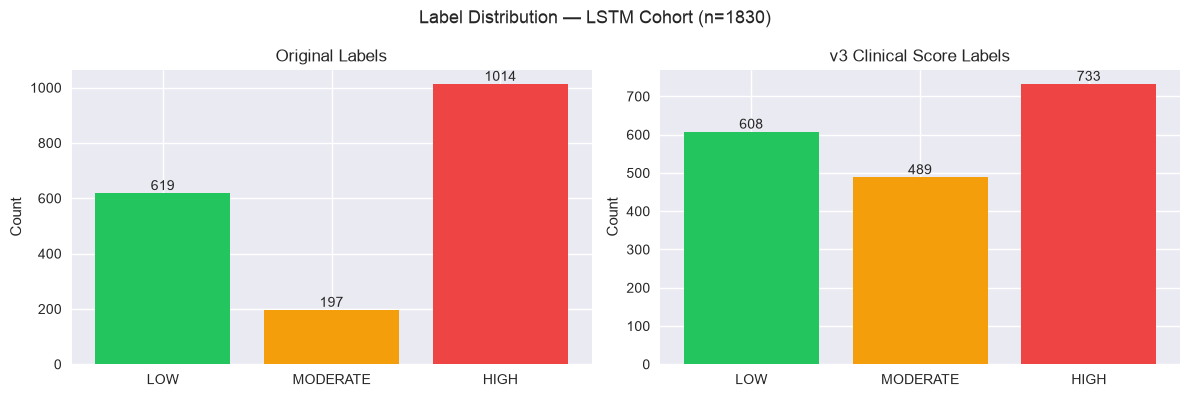

Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_01_label_dist.png


In [3]:
# DIAGRAM 1 — Label distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = {'LOW': '#22c55e', 'MODERATE': '#f59e0b', 'HIGH': '#ef4444'}

for ax, labels, title in zip(
    axes,
    [y_seq_orig_from_csv, y_seq_v3],
    ['Original Labels', 'v3 Clinical Score Labels'],
):
    counts = pd.Series(labels).value_counts().reindex(RISK_CLASSES)
    bars = ax.bar(RISK_CLASSES, counts.values, color=[palette[c] for c in RISK_CLASSES])
    ax.set_title(title)
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{int(val)}',
                ha='center', va='bottom')
plt.suptitle('Label Distribution — LSTM Cohort (n=1830)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_01_label_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "lstm_v3_01_label_dist.png"}')


## Section 2 — Sequence Analysis


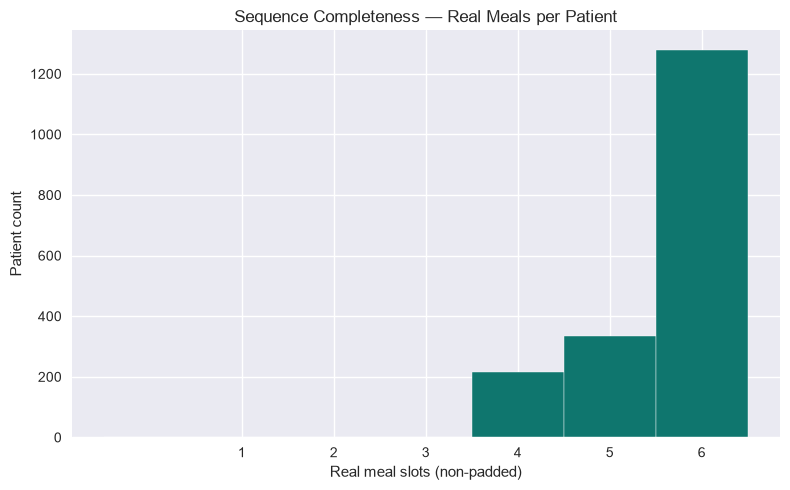

Mean real meals: 5.58 | Min: 4 | Max: 6
Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_02_completeness.png


In [4]:
# DIAGRAM 2 — Sequence completeness
pad_mask_all = (X_seq == 0).all(axis=-1)
real_meals = (~pad_mask_all).sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(real_meals, bins=range(0, 8), color='#0f766e', edgecolor='white', align='left')
ax.set_xlabel('Real meal slots (non-padded)')
ax.set_ylabel('Patient count')
ax.set_title('Sequence Completeness — Real Meals per Patient')
ax.set_xticks(range(1, 7))
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_02_completeness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean real meals: {real_meals.mean():.2f} | Min: {real_meals.min()} | Max: {real_meals.max()}')
print(f'Saved: {FIG_DIR / "lstm_v3_02_completeness.png"}')


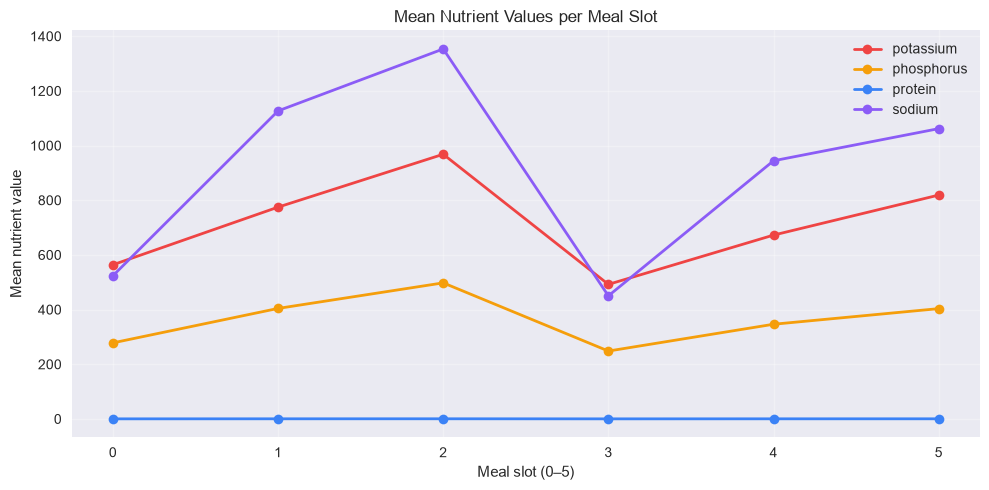

Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_03_slot_means.png


In [5]:
# DIAGRAM 3 — Mean nutrient values per slot
slot_means = []
for slot in range(6):
    slot_means.append([X_seq[:, slot, j].mean() for j in range(4)])

slot_means = np.array(slot_means)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ef4444', '#f59e0b', '#3b82f6', '#8b5cf6']
for j, (name, color) in enumerate(zip(NUTRIENT_NAMES, colors)):
    ax.plot(range(6), slot_means[:, j], 'o-', label=name, color=color, lw=2)
ax.set_xlabel('Meal slot (0–5)')
ax.set_ylabel('Mean nutrient value')
ax.set_title('Mean Nutrient Values per Meal Slot')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_03_slot_means.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "lstm_v3_03_slot_means.png"}')


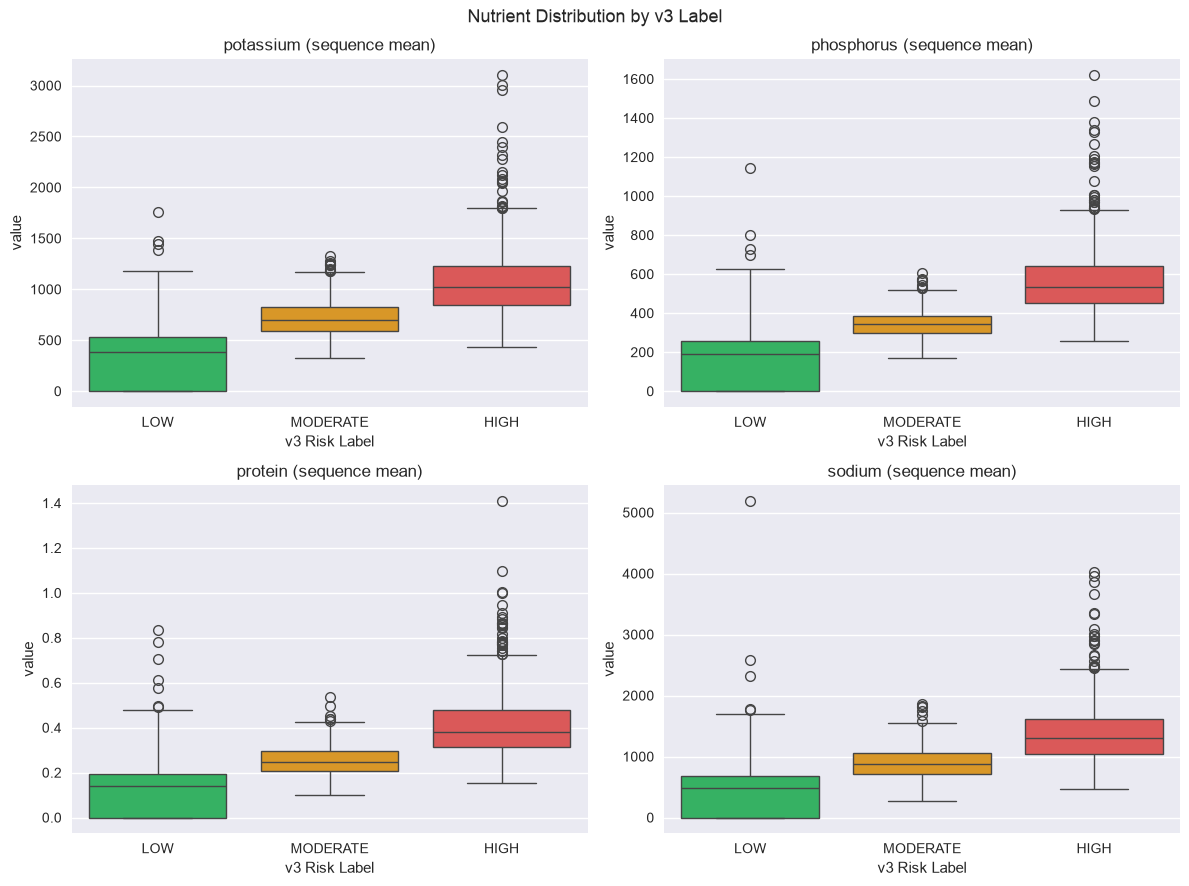

Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_04_nutrient_by_label.png


In [6]:
# DIAGRAM 4 — Nutrient distribution by v3 label
def masked_seq_mean(X, patient_idx):
    mask = ~(X[patient_idx] == 0).all(axis=-1)
    if mask.sum() == 0:
        return np.zeros(4)
    return X[patient_idx, mask, :4].mean(axis=0)

rows = []
for i, label in enumerate(y_seq_v3):
    means = masked_seq_mean(X_seq, i)
    for j, name in enumerate(NUTRIENT_NAMES):
        rows.append({'label': label, 'nutrient': name, 'value': means[j]})
nut_df = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
palette = {'LOW': '#22c55e', 'MODERATE': '#f59e0b', 'HIGH': '#ef4444'}
for ax, nutrient in zip(axes, NUTRIENT_NAMES):
    sub = nut_df[nut_df['nutrient'] == nutrient]
    sns.boxplot(data=sub, x='label', y='value', order=RISK_CLASSES,
                palette=palette, ax=ax)
    ax.set_title(f'{nutrient} (sequence mean)')
    ax.set_xlabel('v3 Risk Label')
plt.suptitle('Nutrient Distribution by v3 Label', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_04_nutrient_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "lstm_v3_04_nutrient_by_label.png"}')


## Section 3 — Preprocessing (Controlled)


In [7]:
y_seq = y_seq_v3
y_encoded = np.array([RISK_ENCODE[r] for r in y_seq])
n_patients, n_steps, n_features = X_seq.shape

print('Label encoding:')
for i, cls in enumerate(RISK_CLASSES):
    print(f'  {i} = {cls}')

# 1. train_test_split
X_train_raw, X_test_raw, y_train, y_test, idx_train, idx_test = train_test_split(
    X_seq, y_encoded, np.arange(n_patients),
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_encoded,
)
print(f'\nTrain: {len(X_train_raw)} | Test: {len(X_test_raw)}')

# 2. StandardScaler fitted on X_train only
scaler = StandardScaler()
scaler.fit(X_train_raw.reshape(-1, n_features))

def scale_sequences(X):
    n = X.shape[0]
    flat = X.reshape(-1, n_features)
    return scaler.transform(flat).reshape(n, n_steps, n_features)

X_train_scaled = scale_sequences(X_train_raw)
X_test_scaled = scale_sequences(X_test_raw)

# 3. MASKING FIX — zero padded slots after scaling
def zero_padded_slots(X_scaled, X_raw):
    X_out = X_scaled.copy()
    pad_mask = (X_raw == 0).all(axis=-1)
    for i in range(X_out.shape[0]):
        X_out[i, pad_mask[i], :] = 0.0
    return X_out

X_train_scaled = zero_padded_slots(X_train_scaled, X_train_raw)
X_test_scaled = zero_padded_slots(X_test_scaled, X_test_raw)

# 4. Truncated-sequence augmentation on X_train_scaled only
def augment_with_truncated_sequences(X, y, n_steps=6):
    X_augmented = [X.copy()]
    y_augmented = [y.copy()]
    for cutoff in range(1, n_steps):
        X_truncated = X.copy()
        X_truncated[:, cutoff:, :] = 0
        X_augmented.append(X_truncated)
        y_augmented.append(y.copy())
    return np.concatenate(X_augmented, axis=0), np.concatenate(y_augmented, axis=0)

X_train_aug, y_train_aug = augment_with_truncated_sequences(
    X_train_scaled, y_train, n_steps=n_steps
)
print(f'Augmented train: {X_train_aug.shape[0]} ({len(X_train_raw)*6} expected)')

# 5. class_weight='balanced'
classes = np.unique(y_train_aug)
class_weights_arr = compute_class_weight('balanced', classes=classes, y=y_train_aug)
class_weight = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print('Class weights:', class_weight)


Label encoding:
  0 = LOW
  1 = MODERATE
  2 = HIGH

Train: 1464 | Test: 366
Augmented train: 8784 (8784 expected)
Class weights: {0: 1.002053388090349, 1: 1.248081841432225, 2: 0.8327645051194539}


## Section 4 — Model Architecture


In [8]:
model = Sequential([
    Masking(mask_value=0.0, input_shape=(n_steps, n_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax'),
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 6, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 6, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,043 (121.26 KB)

 Trainable params: 30,979 (121.01 KB)

 Non-trainable params: 64 (256.00 B)

## Section 5 — Training


In [9]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1,
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1,
)

print('Training LSTM v3...')
t0 = time.time()
history = model.fit(
    X_train_aug, y_train_aug,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight,
    verbose=1,
)

# Save training history
np.save(
    STATS_DIR / 'lstm_v3_history.npy',
    history.history
)
print("History saved.")

print(f'Training done in {time.time()-t0:.1f}s | Best epoch: {len(history.history["loss"]) - early_stop.patience}')


Training LSTM v3...
Epoch 1/100



  1/248 ━━━━━━━━━━━━━━━━━━━━ 6:31 2s/step - accuracy: 0.3125 - loss: 1.3300


 18/248 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3295 - loss: 1.1502 


 35/248 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3780 - loss: 1.0934


 55/248 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4207 - loss: 1.0500

...


Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6817 - loss: 0.6820 - val_accuracy: 0.8248 - val_loss: 0.4138 - learning_rate: 5.0000e-04


Epoch 25: early stopping


Restoring model weights from the end of the best epoch: 15.


History saved.
Training done in 20.1s | Best epoch: 15


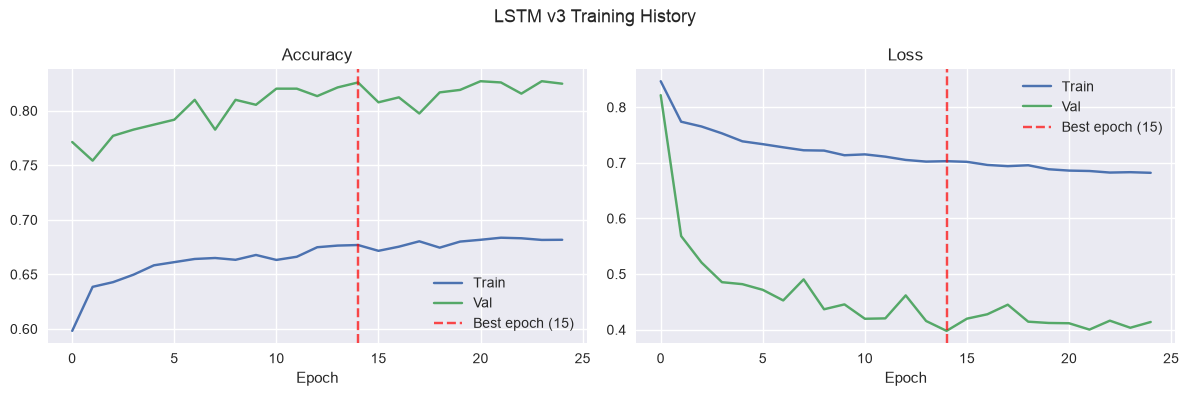

Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_05_training_history.png
Saved: /Users/jade/GUIDAPLATE/outputs/stats/lstm_v3_history.npy


In [ ]:
# DIAGRAM 5 — Training history
best_epoch = np.argmin(history.history['val_loss']) + 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('LSTM v3 Training History', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_05_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "lstm_v3_05_training_history.png"}')
np.save(STATS_DIR / 'lstm_v3_history.npy', history.history)
print(f'Saved: {STATS_DIR / "lstm_v3_history.npy"}')


## Section 6 — Full Evaluation


In [11]:
def class_recall(y_true, y_pred, cls):
    idx = RISK_ENCODE[cls]
    tp = np.sum((y_true == idx) & (y_pred == idx))
    fn = np.sum((y_true == idx) & (y_pred != idx))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def per_class_f1(y_true, y_pred, cls):
    idx = RISK_ENCODE[cls]
    return f1_score(y_true == idx, y_pred == idx, zero_division=0)

# v3 predictions
y_pred_prob_v3 = model.predict(X_test_scaled, verbose=0)
y_pred_v3 = np.argmax(y_pred_prob_v3, axis=1)

v3_accuracy = accuracy_score(y_test, y_pred_v3)
v3_f1 = f1_score(y_test, y_pred_v3, average='weighted', zero_division=0)
v3_auc = roc_auc_score(y_test, y_pred_prob_v3, multi_class='ovr', average='macro')
v3_high_sens = class_recall(y_test, y_pred_v3, 'HIGH')
v3_mod_sens = class_recall(y_test, y_pred_v3, 'MODERATE')

print(classification_report(y_test, y_pred_v3, target_names=RISK_CLASSES, zero_division=0))
print(f'Accuracy: {v3_accuracy:.4f} | F1 weighted: {v3_f1:.4f} | AUC: {v3_auc:.4f}')
print(f'HIGH sens: {v3_high_sens:.4f} | MOD sens: {v3_mod_sens:.4f}')

# v1 and B2 on same test indices (ground truth = v3 labels)
X_v1 = np.load(MODEL_DIR / 'lstm_sequences_cache.npz', allow_pickle=True)['sequences']
v1_model = load_model(MODEL_DIR / 'lstm_final.keras')
v1_scaler = joblib.load(MODEL_DIR / 'lstm_scaler.pkl')
X_test_v1_raw = X_v1[idx_test]
flat = X_test_v1_raw.reshape(-1, 4)
X_test_v1 = v1_scaler.transform(flat).reshape(len(X_test_v1_raw), n_steps, 4)
y_pred_v1 = np.argmax(v1_model.predict(X_test_v1, verbose=0), axis=1)

v2_model = load_model(MODEL_DIR / 'lstm_v2_final.keras')
y_pred_b2 = np.argmax(v2_model.predict(X_test_raw, verbose=0), axis=1)


              precision    recall  f1-score   support

         LOW       0.97      0.97      0.97       121
    MODERATE       0.81      0.92      0.86        98
        HIGH       0.97      0.88      0.93       147

    accuracy                           0.92       366
   macro avg       0.92      0.92      0.92       366
weighted avg       0.93      0.92      0.92       366

Accuracy: 0.9208 | F1 weighted: 0.9219 | AUC: 0.9837
HIGH sens: 0.8844 | MOD sens: 0.9184


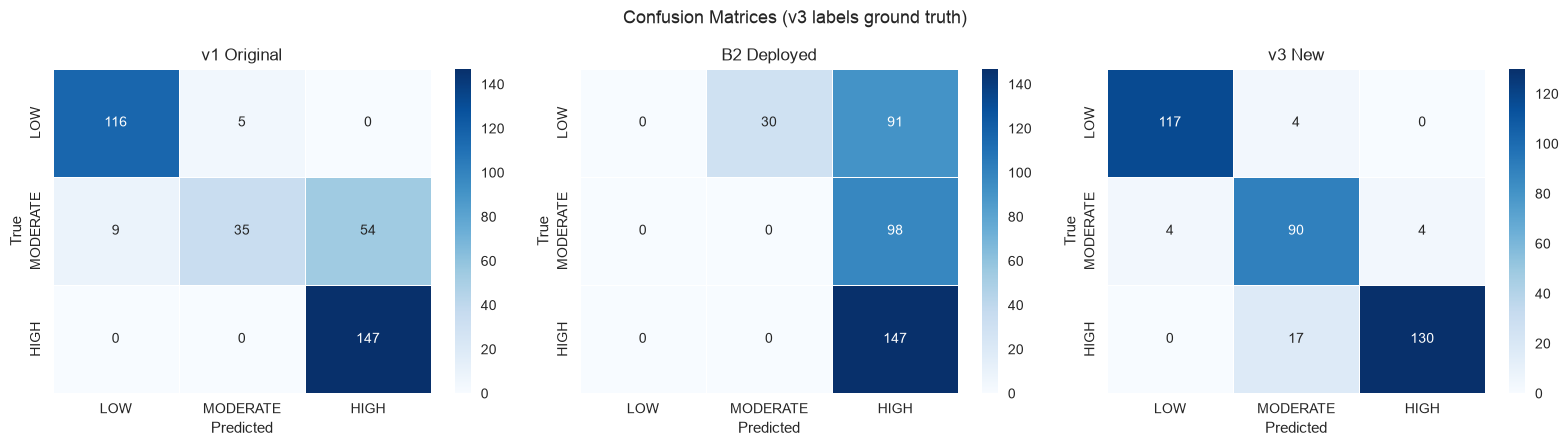

Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_06_confusion.png


In [12]:
# DIAGRAM 6 — Confusion matrices (v1 | B2 | v3)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cms = [
    (confusion_matrix(y_test, y_pred_v1, labels=[0,1,2]), 'v1 Original'),
    (confusion_matrix(y_test, y_pred_b2, labels=[0,1,2]), 'B2 Deployed'),
    (confusion_matrix(y_test, y_pred_v3, labels=[0,1,2]), 'v3 New'),
]
for ax, (cm, title) in zip(axes, cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=RISK_CLASSES, yticklabels=RISK_CLASSES, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices (v3 labels ground truth)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_06_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "lstm_v3_06_confusion.png"}')


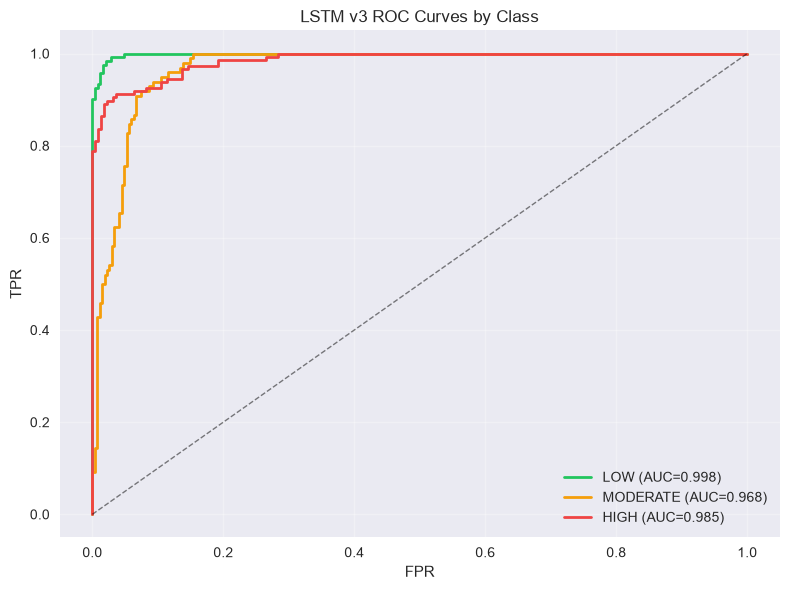

Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_07_roc.png


In [13]:
# DIAGRAM 7 — ROC curves per class (v3)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#22c55e', '#f59e0b', '#ef4444']
for i, (cls, color) in enumerate(zip(RISK_CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob_v3[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('LSTM v3 ROC Curves by Class')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_07_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "lstm_v3_07_roc.png"}')


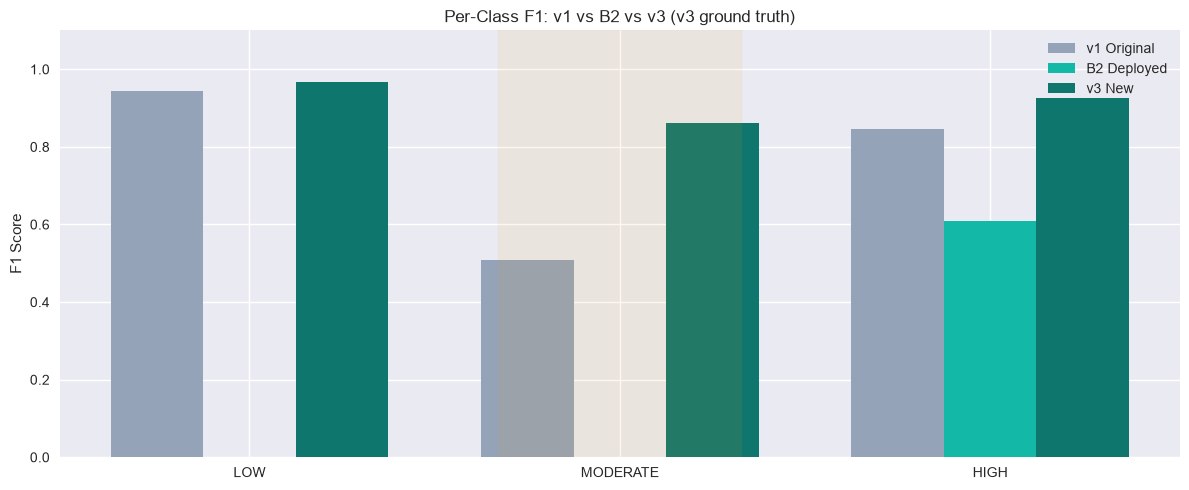

Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_08_f1_comparison.png


In [14]:
# DIAGRAM 8 — Per-class F1: v1 vs B2 vs v3
f1_data = {
    'v1': [per_class_f1(y_test, y_pred_v1, c) for c in RISK_CLASSES],
    'B2': [per_class_f1(y_test, y_pred_b2, c) for c in RISK_CLASSES],
    'v3': [per_class_f1(y_test, y_pred_v3, c) for c in RISK_CLASSES],
}
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(3)
w = 0.25
ax.bar(x - w, f1_data['v1'], w, label='v1 Original', color='#94a3b8')
ax.bar(x, f1_data['B2'], w, label='B2 Deployed', color='#14b8a6')
ax.bar(x + w, f1_data['v3'], w, label='v3 New', color='#0f766e')
ax.set_xticks(x); ax.set_xticklabels(RISK_CLASSES)
ax.set_ylabel('F1 Score'); ax.set_title('Per-Class F1: v1 vs B2 vs v3 (v3 ground truth)')
ax.legend(); ax.set_ylim(0, 1.1)
# Highlight MODERATE
ax.axvspan(0.67, 1.33, alpha=0.08, color='#f59e0b', label='_MOD highlight')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_08_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "lstm_v3_08_f1_comparison.png"}')


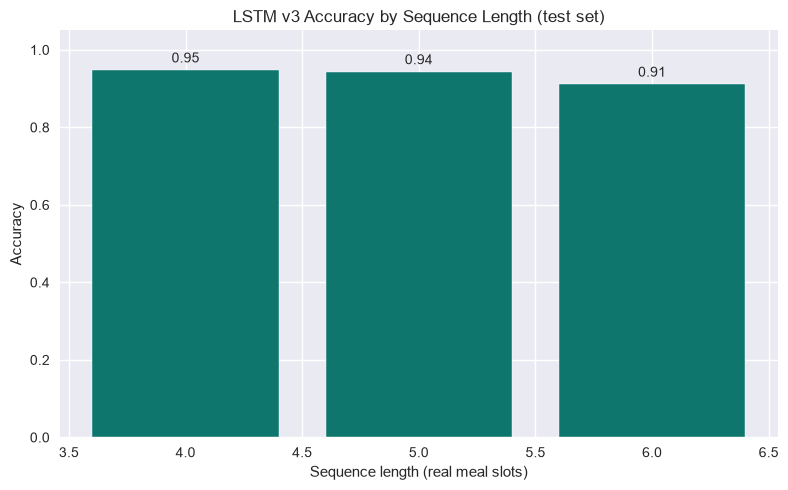

Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_09_length_accuracy.png


In [15]:
# DIAGRAM 9 — Sequence length vs accuracy
test_real_meals = (~(X_test_raw == 0).all(axis=-1)).sum(axis=1)
length_acc = {}
for length in range(1, 7):
    mask = test_real_meals == length
    if mask.sum() == 0:
        continue
    length_acc[length] = accuracy_score(y_test[mask], y_pred_v3[mask])

fig, ax = plt.subplots(figsize=(8, 5))
lengths = sorted(length_acc.keys())
accs = [length_acc[l] for l in lengths]
bars = ax.bar(lengths, accs, color='#0f766e', edgecolor='white')
ax.set_xlabel('Sequence length (real meal slots)')
ax.set_ylabel('Accuracy')
ax.set_title('LSTM v3 Accuracy by Sequence Length (test set)')
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_09_length_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "lstm_v3_09_length_accuracy.png"}')


## Section 7 — Final Comparison + Decision Gate


FINAL COMPARISON TABLE
Metric         | v1 Original  | B2 Deployed  | v3 New      
-----------------------------------------------------------------
Accuracy       |      90.71% |      85.79% |      92.08%
F1 weighted    |       0.9052 |       0.8664 |       0.9219
AUC            |       0.9825 |       0.9543 |       0.9837
HIGH sens      |      93.60% |      88.18% |      88.44%
MOD sens       |          ~0% |      58.97% |      91.84%


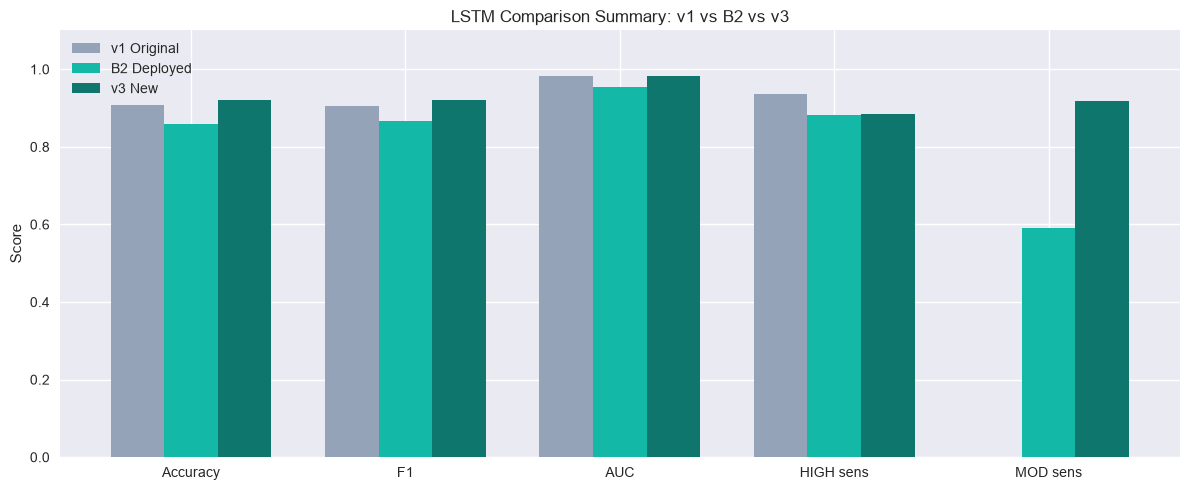

Saved: /Users/jade/GUIDAPLATE/outputs/figures/lstm_v3_10_summary.png


In [16]:
V1_REF = {
    'accuracy': 0.9071, 'f1': 0.9052, 'auc': 0.9825,
    'high_sensitivity': 0.9360, 'mod_sensitivity': 0.0,
}
B2_DEPLOYED = {
    'accuracy': 0.8579, 'f1': 0.8664, 'auc': 0.9543,
    'high_sensitivity': 0.8818, 'mod_sensitivity': 0.5897,
}

print('=' * 65)
print('FINAL COMPARISON TABLE')
print('=' * 65)
print(f"{'Metric':<14} | {'v1 Original':<12} | {'B2 Deployed':<12} | {'v3 New':<12}")
print('-' * 65)
print(f"{'Accuracy':<14} | {V1_REF['accuracy']*100:>10.2f}% | {B2_DEPLOYED['accuracy']*100:>10.2f}% | {v3_accuracy*100:>10.2f}%")
print(f"{'F1 weighted':<14} | {V1_REF['f1']:>12.4f} | {B2_DEPLOYED['f1']:>12.4f} | {v3_f1:>12.4f}")
print(f"{'AUC':<14} | {V1_REF['auc']:>12.4f} | {B2_DEPLOYED['auc']:>12.4f} | {v3_auc:>12.4f}")
print(f"{'HIGH sens':<14} | {V1_REF['high_sensitivity']*100:>10.2f}% | {B2_DEPLOYED['high_sensitivity']*100:>10.2f}% | {v3_high_sens*100:>10.2f}%")
print(f"{'MOD sens':<14} | {'~0%':>12} | {B2_DEPLOYED['mod_sensitivity']*100:>10.2f}% | {v3_mod_sens*100:>10.2f}%")
print('=' * 65)

# DIAGRAM 10 — Full comparison summary
metrics = ['Accuracy', 'F1', 'AUC', 'HIGH sens', 'MOD sens']
v1_vals = [V1_REF['accuracy'], V1_REF['f1'], V1_REF['auc'],
           V1_REF['high_sensitivity'], V1_REF['mod_sensitivity']]
b2_vals = [B2_DEPLOYED['accuracy'], B2_DEPLOYED['f1'], B2_DEPLOYED['auc'],
           B2_DEPLOYED['high_sensitivity'], B2_DEPLOYED['mod_sensitivity']]
v3_vals = [v3_accuracy, v3_f1, v3_auc, v3_high_sens, v3_mod_sens]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics))
w = 0.25
ax.bar(x - w, v1_vals, w, label='v1 Original', color='#94a3b8')
ax.bar(x, b2_vals, w, label='B2 Deployed', color='#14b8a6')
ax.bar(x + w, v3_vals, w, label='v3 New', color='#0f766e')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('Score'); ax.set_title('LSTM Comparison Summary: v1 vs B2 vs v3')
ax.legend(); ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_v3_10_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "lstm_v3_10_summary.png"}')


In [17]:
v3_beats_b2 = (
    v3_accuracy >= B2_DEPLOYED['accuracy'] and
    v3_f1 >= B2_DEPLOYED['f1'] and
    v3_auc >= B2_DEPLOYED['auc'] and
    v3_high_sens >= B2_DEPLOYED['high_sensitivity'] and
    v3_mod_sens >= B2_DEPLOYED['mod_sensitivity']
)
v3_trade_off = (
    v3_mod_sens > B2_DEPLOYED['mod_sensitivity'] + 0.10 and
    v3_accuracy >= B2_DEPLOYED['accuracy'] - 0.03
)

label_encoder = {'classes': RISK_CLASSES, 'encode': RISK_ENCODE}

if v3_beats_b2:
    model.save(MODEL_DIR / 'lstm_v3_final.keras')
    joblib.dump(scaler, MODEL_DIR / 'lstm_v3_scaler.pkl')
    joblib.dump(label_encoder, MODEL_DIR / 'lstm_v3_label_encoder.pkl')
    decision = '✅ V3 beats B2 — deploy to production'
elif v3_trade_off:
    model.save(MODEL_DIR / 'lstm_v3_final.keras')
    joblib.dump(scaler, MODEL_DIR / 'lstm_v3_scaler.pkl')
    joblib.dump(label_encoder, MODEL_DIR / 'lstm_v3_label_encoder.pkl')
    decision = '⚠ V3 TRADE-OFF — review before deploy'
else:
    decision = '❌ V3 does not beat B2'
    print('Keep B2 in production')
    print('Document v3 attempt in Chapter 5')

print(decision)

metrics_out = pd.DataFrame([{
    'model': 'LSTM v3',
    'accuracy': round(v3_accuracy, 4),
    'f1_weighted': round(v3_f1, 4),
    'auc_roc': round(v3_auc, 4),
    'high_sensitivity': round(v3_high_sens, 4),
    'mod_sensitivity': round(v3_mod_sens, 4),
    'decision': decision,
    'v3_beats_b2': v3_beats_b2,
    'v3_trade_off': v3_trade_off,
    'training_samples': len(X_train_aug),
    'test_samples': len(X_test_raw),
    'features_per_step': n_features,
    'epochs_trained': len(history.history['loss']),
    'best_epoch': int(best_epoch),
}])
metrics_path = STATS_DIR / '11_lstm_v3_metrics.csv'
metrics_out.to_csv(metrics_path, index=False)
print(f'\nSaved: {metrics_path}')
print('models/lstm_v2_final.keras untouched.')
print('NOTEBOOK 05c COMPLETE')


✅ V3 beats B2 — deploy to production

Saved: /Users/jade/GUIDAPLATE/outputs/stats/11_lstm_v3_metrics.csv
models/lstm_v2_final.keras untouched.
NOTEBOOK 05c COMPLETE
